In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import PIL


from tensorflow import keras
from tensorflow.keras import layers # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from keras.models import load_model
import pathlib

In [2]:
#Pega o diretório com as imagens usando Pathlib
data_dir = pathlib.Path("C:/Users/samuc/Downloads/dogs_vs_cats") #Urls "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"  https://www.kaggle.com/datasets/kausthubkannan/5-flower-types-classification-dataset/data
 
#Define o tamanho dos batchs e o tamnaho padrão das imagens / Define qual parte das imagens será de Treinamento e qual será de Validação 
batch_size = 32
img_height = 128
img_width = 128
train_ds = tf.keras.utils.image_dataset_from_directory(data_dir, validation_split=0.2, subset="training", seed=123, image_size=(img_height, img_width), batch_size=batch_size)
val_ds = tf.keras.utils.image_dataset_from_directory(data_dir, validation_split=0.2, subset="validation", seed=123, image_size=(img_height, img_width), batch_size=batch_size)
class_names = train_ds.class_names
num_classes = len(class_names)

#Insere os dados na memória cache e sobrepõe o pré-processamento dos dados e a execução do modelo durante a fase de treinamento 
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

#Faz o aumento do Dataset modificando as imagens existentes 
data_augmentation = Sequential(
  [
    layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

#Cria as camadas da Rede Neural Convolucional junto das camadas Fully-Conected(Dense) usando o Sequential do Keras
model = Sequential([
  #Input Block
  data_augmentation,
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)), #Transforma os valores dos pixels da imagem de 1/255 para 0/1
  #Block 1
  layers.Conv2D(32, 3, padding='same', activation='relu'), #Faz a convolução das imagens com 16 filtros deixando elas com o mesmo tamanho e utilizando da função de ativação Relu
  layers.BatchNormalization(), #Faz a normalização das imagens fazendo uma relação entre a média e a variância dos valores das imagens
  layers.MaxPooling2D(), #Diminui o tamanho da imagem utilizando do MaxPooling de tamanho 2x2
  layers.Dropout(0.2), #Desativa aleatóriamente alguns neurônios 
  #Block 2
  layers.Conv2D(64, 3, padding='same', activation='relu'), #Faz a convolução das imagens com 32 filtros deixando elas com o mesmo tamanho e utilizando da função de ativação Relu
  layers.BatchNormalization(), #Faz a normalização das imagens fazendo uma relação entre a média e a variância dos valores das imagens
  layers.MaxPooling2D(), #Diminui o tamanho da imagem utilizando do MaxPooling de tamanho 2x2
  layers.Dropout(0.2), #Desativa aleatóriamente alguns neurônios 
  #Block 3
  layers.Conv2D(128, 3, padding='same', activation='relu'), #Faz a convolução das imagens com 16 filtros deixando elas com o mesmo tamanho e utilizando da função de ativação Relu
  layers.BatchNormalization(), #Faz a normalização das imagens fazendo uma relação entre a média e a variância dos valores das imagens
  layers.MaxPooling2D(), #Diminui o tamanho da imagem utilizando do MaxPooling de tamanho 2x2
  layers.Dropout(0.2), #Desativa aleatóriamente alguns neurônios 
  #Block 4
  layers.Conv2D(256, 3, padding='same', activation='relu'), #Faz a convolução das imagens com 16 filtros deixando elas com o mesmo tamanho e utilizando da função de ativação Relu
  layers.BatchNormalization(), #Faz a normalização das imagens fazendo uma relação entre a média e a variância dos valores das imagens
  layers.MaxPooling2D(), #Diminui o tamanho da imagem utilizando do MaxPooling de tamanho 2x2
  layers.Dropout(0.2), #Desativa aleatóriamente alguns neurônios  
  #Fully Connected
  layers.Flatten(), #Vetoriza as matrizes dos tensores
  layers.Dense(512, activation='relu'), #Primeira camada Fully-Connected 
  layers.BatchNormalization(), #Faz a normalização das imagens fazendo uma relação entre a média e a variância dos valores das imagens
  layers.Dropout(0.2), #Desativa aleatóriamente alguns neurônios 
  layers.Dense(num_classes, activation='softmax')#Camada de saída da Rede, Onde cada  neurônio é uma classe 
])
#Define qual será a função de perda e qual será o modelo de optimização do Back-propagation
model.compile(optimizer='adam', #Utiliza do algoritmo otimizador Adaptative Moment estimation para as camadas convolucionais 
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),  #Utiliza da função de perda Cross Entropy para a parte Fully-Connected da rede
              metrics=['accuracy'])
model.build((None, 128, 128, 3)) #Executa as camadas 
model.summary(expand_nested=True) #Printa como estão alocadas as camadas da rede 

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 128, 128, 3)       0         
|¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯|
| random_flip (RandomFlip)  (None, 128, 128, 3)       0         |
|                                                               |
| random_rotation (RandomRota  (None, 128, 128, 3)    0         |
| tion)                                                         |
|                                                               |
| random_zoom (RandomZoom)  (None, 128, 128, 3)       0         |
¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯
 rescaling (Rescaling)       (None, 128, 128, 3)       0         
                                     

In [3]:
#Faz o treinamento da rede utilizando do modelo criado 
epochs=1
history = model.fit(
  train_ds, #Dataset de treinamento
  validation_data=val_ds, #Dataset de validação
  epochs=epochs #Número de épocas 
)

 53/625 [=>............................] - ETA: 2:30 - loss: 0.9968 - accuracy: 0.5896

ResourceExhaustedError: Graph execution error:

Detected at node 'gradient_tape/sequential_1/batch_normalization/FusedBatchNormGradV3' defined at (most recent call last):
    File "c:\Users\samuc\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 197, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "c:\Users\samuc\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "C:\Users\samuc\AppData\Roaming\Python\Python39\site-packages\ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "C:\Users\samuc\AppData\Roaming\Python\Python39\site-packages\traitlets\config\application.py", line 1075, in launch_instance
      app.start()
    File "C:\Users\samuc\AppData\Roaming\Python\Python39\site-packages\ipykernel\kernelapp.py", line 739, in start
      self.io_loop.start()
    File "C:\Users\samuc\AppData\Roaming\Python\Python39\site-packages\tornado\platform\asynci

In [4]:
print(history.history['val_accuracy'])

[0.6899999976158142, 0.7544000148773193, 0.7997999787330627, 0.751800000667572, 0.7333999872207642, 0.8330000042915344, 0.8601999878883362, 0.7214000225067139, 0.817799985408783, 0.8863999843597412, 0.8123999834060669, 0.8068000078201294, 0.881600022315979, 0.8827999830245972, 0.7781999707221985, 0.9164000153541565, 0.9175999760627747, 0.8996000289916992, 0.8902000188827515, 0.8980000019073486, 0.8895999789237976, 0.909600019454956, 0.8962000012397766, 0.8845999836921692, 0.8885999917984009, 0.8759999871253967, 0.8823999762535095, 0.9121999740600586, 0.8999999761581421, 0.9028000235557556]


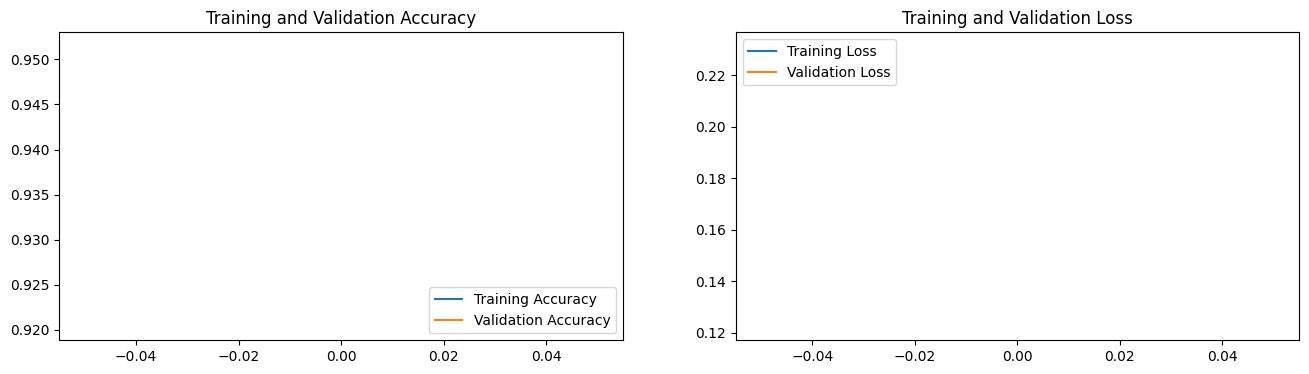

In [17]:
#Faz um gráfico utilizando da Acurácia e da Perda entre os dados de Treinamento e os Dados de Validação
plt.figure(figsize=(16, 4)) #Tamanho da imagem

plt.subplot(1, 2, 1) #Tamanho da Sub-Imagem da Esquerda
plt.plot(range(epochs), history.history['accuracy'], label='Training Accuracy') #Dados de Acurácia dos dados de treino para sub-imagem da esquerda
plt.plot(range(epochs),  history.history['val_accuracy'], label='Validation Accuracy') #Dados de Acurácia dos dados de validação para sub-imagem da esquerda
plt.legend(loc='lower right') #Local da legenda da sub-imagem da esquerda
plt.title('Training and Validation Accuracy') #Título da sub-imagem da esquerda

plt.subplot(1, 2, 2) #Tamanho da Sub-Imagem da Direita
plt.plot(range(epochs), history.history['loss'], label='Training Loss') #Dados da Perda dos dados de treino para sub-imagem da direita
plt.plot(range(epochs), history.history['val_loss'], label='Validation Loss') #Dados da Perda dos dados de validação para sub-imagem direita
plt.legend(loc='upper left') #Local da legenda da sub-imagem da direita
plt.title('Training and Validation Loss') #Título da sub-imagem da direita 
plt.show()

In [20]:
dogs = list(data_dir.glob('dogs/*')) #Carrega todas as imagens dos cachorros do Dataset em uma lista
cats = list(data_dir.glob('cats/*')) #Carrega todas as imagens dos gatos do Dataset em uma lista
im = PIL.Image.open(dogs[121])

1/1 [==============================] - 0s 89ms/step
Essa imagem pertence a classe Dogs com 64.59 porcento de predicão.


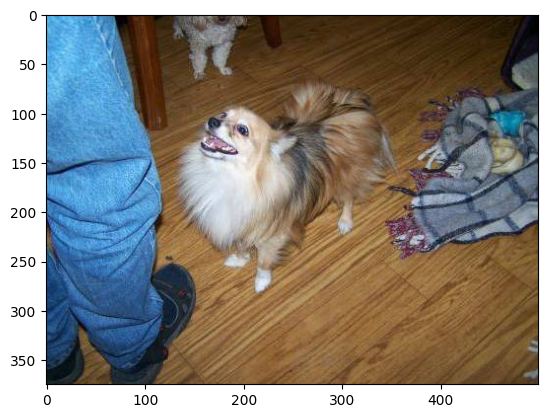

In [21]:

#im = PIL.Image.open('C:/Users/davic/Downloads/Tulips.JPEG') #Carrega uma das imagens em uma variável
plt.imshow(im) #Printa a imagem
im = im.resize((128,128)) #Rescala a Imagem no formato 180x180
im_array = np.array(im) #Vetoriza a imagem no formato 180x180
im_array = np.expand_dims(im_array, axis = 0) #Rescalona a imagem no formato 180x180x1 para ficar no estilo do Keras/TEnsorFlow
score = model.predict(im_array) #Faz a predição da imagem

print("Essa imagem pertence a classe {} com {:.2f} porcento de predicão.".format(class_names[np.argmax(score)], 100 * np.max(score))) #Printa o score da imagem dizendo a qual classe ela pertence 